# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Напишите заголовок первой части проекта здесь

- Автор: Латыпов Эльдар Рафаэлевич
- Дата: 10.05.2025

## Цели и задачи проекта

<b>Цель:</b>

Выявить: действительно ли пользователи сервиса Яндекс-книг  из Санкт-Петербурга более активные, чем пользователи из Москвы

<b>Задачи:</b>

- Загрузить данные из файла yandex_knigi_data.csv.
- Проверить наличие дубликатов в идентификаторах пользователей.
- Сравнить размеры групп, их статистики и распределение.
- Провести статистическую проверку гипотезы о различии среднего времени активности.

## Описание данных

Таблица yandex_knigi_data содержит данные об активности пользователей и состоит из следующих полей:
- <b>Unnamed</b>: индентификатор строки
- <b>city:</b> наименование города пользователя. Принимает два значения: 'Москва' и 'Санкт-Петербург'
- <b>puid:</b> идентификатор пользователя
- <b>hours:</b> сумма часов активности пользователя, в часах

## Содержимое проекта

- Загрузка данных и знакомство с ними

- Предобработка данных

- Проверка гипотезы 

- Составление аналитической записки

---

## 1. Загрузка данных и знакомство с ними

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import numpy as np
import statsmodels.api as sm

In [2]:
knigi_data = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

In [3]:
print(knigi_data.info())
display(knigi_data)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB
None


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434
...,...,...,...
8779,Санкт-Петербург,1130000028554332,4.107774
8780,Санкт-Петербург,1130000030307246,45.069222
8781,Санкт-Петербург,1130000038726322,0.211944
8782,Санкт-Петербург,1130000047892100,4.311841


In [4]:
duplicates_key=knigi_data.duplicated(subset='puid').sum()
print(f"Дубликаты по puid: {duplicates_key}")

Дубликаты по puid: 244


In [5]:
knigi_data= knigi_data.drop_duplicates(subset='puid', keep='first')

## 2. Проверка гипотезы в Python

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [6]:
moscow_users=knigi_data[knigi_data['city']=='Москва']['hours']
spb_users=knigi_data[knigi_data['city']=='Санкт-Петербург']['hours']
print("Москва:")
print(f'Кол-во пользователей {len(moscow_users)}')
print(f'Среднее кол-во активных часов: {round(moscow_users.mean(),2)}')
print(f'Медиана: {round(moscow_users.median(),2)}')
print(f'Среднее отклонение: {round(moscow_users.std(),2)}')
print(f'Максимальное: {round(moscow_users.max(),2)}')
print(f'Минимальное: {round(moscow_users.min(),2)}')

print()
print("Санкт-Петербург:")
print(f'Кол-во пользователей {len(spb_users)}')
print(f'Среднее кол-во активных часов: {round(spb_users.mean(),2)}')
print(f'Медиана: {round(spb_users.median(),2)}')
print(f'Среднее отклонение: {round(spb_users.std(),2)}')
print(f'Максимальное: {round(spb_users.max(),2)}')
print(f'Минимальное: {round(spb_users.min(),2)}')

Москва:
Кол-во пользователей 6234
Среднее кол-во активных часов: 10.88
Медиана: 0.92
Среднее отклонение: 36.85
Максимальное: 857.21
Минимальное: 0.0

Санкт-Петербург:
Кол-во пользователей 2306
Среднее кол-во активных часов: 11.26
Медиана: 0.88
Среднее отклонение: 39.83
Максимальное: 978.76
Минимальное: 0.0


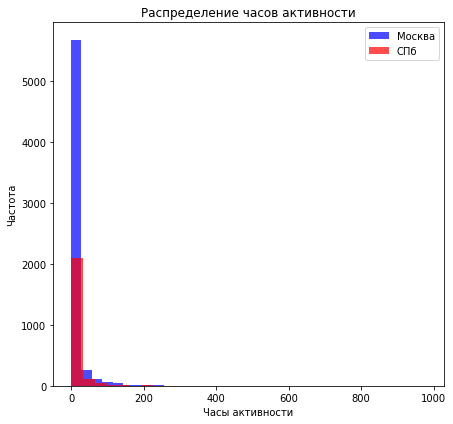

In [7]:
plt.figure(figsize=(12, 6))

# Гистограммы
plt.subplot(1, 2, 1)
plt.hist(moscow_users, bins=30, alpha=0.7, label='Москва', color='blue')
plt.hist(spb_users, bins=30, alpha=0.7, label='СПб', color='red')
plt.xlabel('Часы активности')
plt.ylabel('Частота')
plt.title('Распределение часов активности')
plt.legend()



plt.tight_layout()
plt.show()

На графике изображена гистограмма распределения часов активности по Москве и Санкт-Петербургу. распределение часов активности в обеих группах асимметрично— основная масса пользователей сконцентрирована в левой части графика (низкие значения активности), а справа наблюдается «длинный хвост» из пользователей с высокой активностью. Самая высокая частота наблюдений (более 5000) сосредоточена в районе 0 часов активности — большинство пользователей в обеих группах практически не взаимодействуют с приложением

Для сравнения распределения часов активности пользователей в Москве и Санкт‑Петербурге лучше всего подойдёт тест Манна–Уитни (U-тест):
- Данные не являются нормально распределёнными
- Наличие выбросов
- Независимые выборки

In [8]:
stat, p_value = mannwhitneyu(spb_users, moscow_users, alternative='greater')

print(f"U-статистика: {stat}")
print(f"p-value: {p_value}")

# Интерпретация результата
alpha = 0.05  # уровень значимости
if p_value < alpha:
    print("Отклоняем H₀: среднее время активности в СПб статистически значимо больше, чем в Москве.")
else:
    print("Нет оснований отклонять H₀: нет достаточных доказательств, что среднее время активности в СПб больше.")

U-статистика: 7157178.5
p-value: 0.6189600878052618
Нет оснований отклонять H₀: нет достаточных доказательств, что среднее время активности в СПб больше.


## 3. Аналитическая записка
По результатам анализа данных подготовим аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



<b>Выбор статистического теста</b>
Для сравнения распределений выбран U-тест Манна–Уитни (тест Манна–Уитни) по следующим причинам:

- данные не являются нормально распределёнными (асимметричное распределение, видно на гистограмме);
- присутствуют выбросы (длинные хвосты на гистограмме, максимальные значения до 1 000 часов);
- выборки независимы (данные по двум городам).

Уровень статистической значимости (α): 0,05 (стандартный выбор).

Тип проверки: односторонняя (так как H₁ предполагает строгое превышение среднего значения для Санкт-Петербурга).

<b>Результаты теста:</b>

U-статистика: 7157178.5

p-value: 0.6189600878052618 

<b>Вывод: </b>Тест показал, что нет достаточных доказательств для отклонения нулевой гипотезы. Различия в среднем времени активности могут быть случайными, и нет оснований утверждать, что пользователи из Санкт-Петербурга более активны.
 
Возможные причины результата: 
- Распределение пользователей по часам активности у двух городах примерно одинаковы
- В Москве пользователей намного больше чем в Питере 
- В двух городах есть аномальные значения активности пользователей
- Активность в двух городах действительно одинакова



----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Опишите цели исследования.



<b>Основная цель</b>: оценить, повышает ли новая версия сайта конверсию в покупку по сравнению со старой.

<b>План оценки A/B‑теста:</b>
 1) Проверить корректность теста
 
 2) ПРоанализировать результаты
 
 3) Провести статистическую проверку гипотезы
 
 4) Сделать выводы теста


## 2. Загрузите данные, оцените их целостность.


In [9]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [10]:
print(participants.info())
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB
None


In [11]:
print('5 строк таблицы о пользователях')
display(participants.head())

print('5 строк таблицы об активности')
display(events.head())

5 строк таблицы о пользователях


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


5 строк таблицы об активности


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [12]:

duplicates_user=participants.duplicated().sum()
print(f'Дубликаты по всем столбцам таблицы participants: {duplicates_user}')
duplicates_userid=participants.duplicated(subset='user_id').sum()
print(f'Дубликаты по "user_id" таблицы participants: {duplicates_userid}')
print(f'Дубликаты по "user_id" таблицы participants по стоблцам "user_id","group", "ab_test": {participants.duplicated(subset=["user_id","group", "ab_test"]).sum()}')
duplicates=events.duplicated().sum()
print(f'Дубликаты по всем столбцам таблицы events: {duplicates}')
duplicates_events=events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()
print(f'Дубликаты по столбцам "user_id", "event_dt", "event_name" таблицы events: {duplicates_events}')

Дубликаты по всем столбцам таблицы participants: 0
Дубликаты по "user_id" таблицы participants: 887
Дубликаты по "user_id" таблицы participants по стоблцам "user_id","group", "ab_test": 0
Дубликаты по всем столбцам таблицы events: 36318
Дубликаты по столбцам "user_id", "event_dt", "event_name" таблицы events: 39510


In [13]:
print(f"Уникальные значения столбца group таблицы participants: {participants['group'].unique().tolist()}")
print(f"Уникальные значения столбца ab_test таблицы participants: {participants['ab_test'].unique().tolist()}")
print(f"Уникальные значения столбца group таблицы participants: {participants['device'].unique().tolist()}")
print()
print(f"Уникальные значения столбца event_name таблицы events: {events['event_name'].unique().tolist()}")

Уникальные значения столбца group таблицы participants: ['B', 'A']
Уникальные значения столбца ab_test таблицы participants: ['interface_eu_test', 'recommender_system_test']
Уникальные значения столбца group таблицы participants: ['Mac', 'Android', 'iPhone', 'PC']

Уникальные значения столбца event_name таблицы events: ['End of Black Friday Ads Campaign', 'registration', 'product_page', 'login', 'product_cart', 'purchase', 'Start of Christmas&New Year Promo', 'Start of CIS New Year Gift Lottery']


In [14]:
print(f'Количество строк таблицы events со значение "GLOBAL" в столбце user_id: {events[events["user_id"]=="GLOBAL"]["user_id"].count()}')

Количество строк таблицы events со значение "GLOBAL" в столбце user_id: 58495


In [15]:
print(f'Дубликаты по столбцам "user_id", "event_dt", "event_name" таблицы events без  значения "GLOBAL" в столбце user_id: {events[events["user_id"]!="GLOBAL"].duplicated(subset=["user_id", "event_dt", "event_name"]).sum()}')

Дубликаты по столбцам "user_id", "event_dt", "event_name" таблицы events без  значения "GLOBAL" в столбце user_id: 38660


<b>Вывод:</b>
- Таблица о пользователях содержит данные о его индентификаторе, устройсве, группе теста(А или В), а так же о самом тесте, т.е в таблицу попало два теста 'interface_eu_test' и 'recommender_system_test', поэтому таблица имеет 887 дубликата по user_id, уникальные значения в солбцах не имеют ошибок, наименование столбцев корректны, тип данных правильные, пропусков нет

- Таблица об активностях содержит следующие данные: индентификатор пользователя, дата события, название события и детали. Таблица имеет 36318 дубликата по всем столбцам и 39510 дубликата по всем столбцам кроме деталей. Уникальные значения в солбцах не имеют ошибок, наименование столбцев корректны, тип данных правильные, пропуски встречаются только в столбце о деталях, что некритично. В стоблце user_id 58495 раз встречается значение "GLOBAL", если не считать данное значение то талбица имеет 38660 дубликатов 

<b>Рекомендации</b>
- Проверить пересечение пользователей в двух конкурирующих тестах (interface_eu_test и recommender_system_test) 
- Следует отобрать пользователей с тестом  'interface_eu_test', в случае образований дубликатов удалить их,   
- Отчистить таблицу о событях от значения "GLOBAL" и удалить дубликаты 

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [16]:
group_test=participants.groupby('ab_test')['user_id'].nunique().reset_index()
group_test.columns=['ab_test', 'user_id']

In [17]:
user_counts = group_test['user_id'].value_counts()
double_users_v2 = user_counts[user_counts > 1].index.tolist()
print(f"Количество пользователей, которые встречаются в обеих тестах: {len(double_users_v2)}")

Количество пользователей, которые встречаются в обеих тестах: 0


Техническому заданию соответсвуют пользователи с теста "interface_eu_test", отберем пользователей этого теста 

In [18]:
ab_test_participants=participants[participants['ab_test']=='interface_eu_test']


In [19]:
count_a= len(ab_test_participants[ab_test_participants['group']=='A']) 
count_b= len(ab_test_participants[ab_test_participants['group']=='B'])
prozent= round(100*abs(count_a-count_b)/count_a,2)
print(f"Кол-во пользователей в группе А: {count_a}")
print(f"Кол-во пользователей в группе B: {count_b}")
print(f"Разница между группами в %: {prozent}")

Кол-во пользователей в группе А: 5383
Кол-во пользователей в группе B: 5467
Разница между группами в %: 1.56


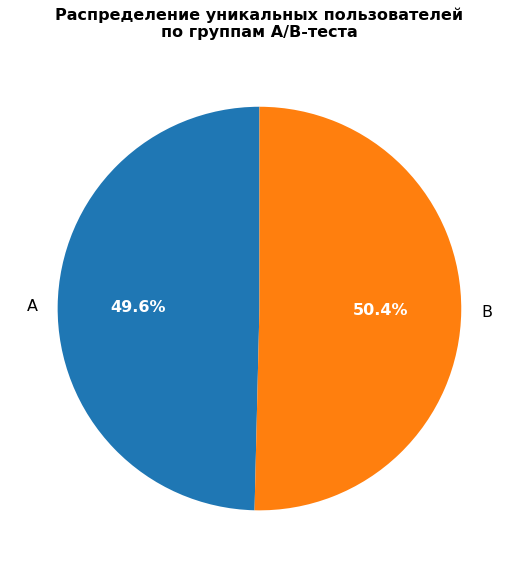

In [20]:
plt.figure(figsize=(8, 8))

ab_group= ab_test_participants.groupby('group')['user_id'].nunique().reset_index()
ab_group.columns=['test_group', 'user_id_count']
wedges, texts, autotexts = plt.pie(
    ab_group['user_id_count'],
    labels=ab_group['test_group'],
    autopct='%1.1f%%', 
    startangle=90, 
    textprops={'fontsize': 16}  
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')


plt.title('Распределение уникальных пользователей\nпо группам A/B-теста', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

На графике представлено распределение уникальных пользователей по группам A/B-теста. Группа «А» включает 50,4% пользователей, группа «В» — 49,6%. Распределение практически равномерное, разница между группами минимальна (всего 0,8 п.п.). Это обеспечивает сопоставимость условий для сравнения результатов теста

In [21]:
user_counts = ab_test_participants['user_id'].value_counts()
double_users_v2 = user_counts[user_counts > 1].index.tolist()
print(f"Количество пользователей, которые встречаются в обеих группах: {len(double_users_v2)}")

Количество пользователей, которые встречаются в обеих группах: 0


3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [22]:
ab_test_events=events[events['user_id']!='GLOBAL'] 
ab_test_events=pd.merge(ab_test_events, ab_test_participants, on='user_id', how='inner')
print(ab_test_events.info())
display(ab_test_events.head(10))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 79715 entries, 0 to 79714
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     79715 non-null  object        
 1   event_dt    79715 non-null  datetime64[ns]
 2   event_name  79715 non-null  object        
 3   details     21075 non-null  object        
 4   group       79715 non-null  object        
 5   ab_test     79715 non-null  object        
 6   device      79715 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.9+ MB
None


,user_id,event_dt,event_name,details,group,ab_test,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone
5,5F506CEBEDC05D30,2020-12-10 23:18:00,product_page,NaN,A,interface_eu_test,iPhone
6,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,A,interface_eu_test,Android
7,51278A006E918D97,2020-12-07 01:49:18,login,NaN,A,interface_eu_test,Android
8,51278A006E918D97,2020-12-07 01:49:19,login,NaN,A,interface_eu_test,Android
9,51278A006E918D97,2020-12-09 02:12:06,product_cart,NaN,A,interface_eu_test,Android


In [23]:
print(f"Найдено {ab_test_events.duplicated().sum()} дубликатов")

Найдено 6170 дубликатов


In [24]:
ab_test_events=ab_test_events.drop_duplicates(keep='first')
print(F"Проверка дубликатов после их удаления{ab_test_events.duplicated().sum()}")

Проверка дубликатов после их удаления0


- определим горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [25]:
registration_user=ab_test_events[ab_test_events['event_name']=='registration'][['event_dt','user_id']]
registration_user= registration_user.rename(columns={'event_dt': 'registration_dt'})
ab_test_events=pd.merge(ab_test_events,registration_user, on='user_id',how='inner' )
ab_test_events['lifetime_days']=(ab_test_events['event_dt']-ab_test_events['registration_dt']).dt.days
ab_test_events=ab_test_events[(ab_test_events['lifetime_days']<=7)&(ab_test_events['lifetime_days']>=0)]


In [26]:
print(f'Кол-во событий, выполненные в течении 7 дней после регистрации: {len(ab_test_events)}')
display(ab_test_events)

Кол-во событий, выполненные в течении 7 дней после регистрации: 65422


,user_id,event_dt,event_name,details,group,ab_test,device,registration_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone,2020-12-06 14:10:01,0
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01,0
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01,0
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01,2
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01,2
...,...,...,...,...,...,...,...,...,...
73540,16CCB1C8C4DCF1AF,2020-12-23 23:50:29,registration,0.0,A,interface_eu_test,Mac,2020-12-23 23:50:29,0
73541,16CCB1C8C4DCF1AF,2020-12-23 23:55:52,login,NaN,A,interface_eu_test,Mac,2020-12-23 23:50:29,0
73542,2DDC948BD76ABC57,2020-12-24 21:57:10,registration,-4.29,B,interface_eu_test,iPhone,2020-12-24 21:57:10,0
73543,2DDC948BD76ABC57,2020-12-24 21:58:49,login,NaN,B,interface_eu_test,iPhone,2020-12-24 21:57:10,0


Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [27]:
alpha = 1-0.95   # Уровень значимости
beta = 1-0.8  # Ошибка второго рода, часто 1 - мощность
power = 0.8 # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [28]:
group_a=ab_test_events[ab_test_events['group']=='A']
group_b=ab_test_events[ab_test_events['group']=='B']


purchases_a = group_a[group_a['event_name'] == 'purchase']['user_id'].nunique()
total_a = group_a[group_a['event_name'] == 'registration']['user_id'].nunique()

# Для группы B
purchases_b = group_b[group_b['event_name'] == 'purchase']['user_id'].nunique()
total_b = group_b[group_b['event_name'] == 'registration']['user_id'].nunique()

print(f"Группа A: покупок — {purchases_a}, всего посетителей — {total_a}, в относительном значении {round(purchases_a/total_a*100, 2)}%")
print(f"Группа B: покупок — {purchases_b}, всего посетителей — {total_b}, в относительном значении {round(purchases_b/total_b*100, 2)}%")
print(f"Разница относительных значерий {round(abs(round(purchases_a/total_a*100, 2)-round(purchases_b/total_b*100, 2)),2)}%")

Группа A: покупок — 1542, всего посетителей — 5383, в относительном значении 28.65%
Группа B: покупок — 1687, всего посетителей — 5467, в относительном значении 30.86%
Разница относительных значерий 2.21%


- сделаем предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

В ходе анализа пользовательской активности в тестовых группах, было выявлено, что в группе В пользователи на 2.21% больше делали покупку, чем в группе А. Следовательно, новый интерфейс сайта благоприятное складывается на совершении покупок, но не на 3п.п.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Для сравнения конверсий (долей) между двумя независимыми группами (A и B) в A/B-тесте наиболее подходящим статистическим тестом является z-тест для пропорций. Этот тест позволяет проверить гипотезу о том, что разница в конверсиях между группами статистически значима

<ul><li>$H_0$: упрощение интерфейса не приведет к увилечению конверсии зарегистрированных пользователей в покупателей на три процентных пункта</li><li>$H_1$: упрощение интерфейса приведет к увилечению конверсии зарегистрированных пользователей в покупателей на три процентных пункта</div>

In [29]:
count = np.array([purchases_a, purchases_b])
nobs = np.array([total_a, total_b])

z_stat, p_value = sm.stats.proportions_ztest(count, nobs, alternative='smaller')

alpha = 0.05
if p_value < alpha:
    print(f"\nВывод: Разница статистически значима (p < {alpha})")
    print("Отклоняем нулевую гипотезу: конверсии групп различаются")
else:
    print(f"\nВывод: Разница не является статистически значимой (p >= {alpha})")
    print("Не можем отклонить нулевую гипотезу")


Вывод: Разница статистически значима (p < 0.05)
Отклоняем нулевую гипотезу: конверсии групп различаются


<b>Интерпретация результатов</b>

 <b>Статистическая значимость.</b> 
 
 Значение p<0,05 означает, что вероятность получить такую или большую разницу между группами при условии истинности H0 составляет менее 5%. Это позволяет отклонить нулевую гипотезу и сделать вывод о наличии реального различия между группами.

Величина эффекта. Конверсия в тестовой группе (30,86%) выше, чем в контрольной (28,65%), на 2,21 п. п. Однако это меньше целевого прироста в 3 п. п., заявленного в альтернативной гипотезе H 

Сравнение с базовым показателем. Базовый уровень конверсии составлял 30%. В контрольной группе конверсия ниже (28,65%), а в тестовой — немного выше (30,86%). Это может указывать на:

- естественные колебания конверсии;

- влияние внешних факторов на контрольную группу;

- частичный успех изменений в интерфейсе.

<b>Практическая значимость.</b> Хотя разница статистически значима, прирост в 2,21 п. п. может быть недостаточно велик для оправдания затрат на внедрение новой версии сайта, если целевой ориентир был 3 п. п. Важно оценить:

- экономический эффект от дополнительного 2,21% конверсии;

- стоимость поддержки новой версии сайта;

- возможные долгосрочные эффекты (например, улучшение пользовательского опыта).

<b>Выводы</b>
- Тест проведён корректно: выборка достаточна, результаты статистически значимы (p<0,05).

- Изменения в интерфейсе оказали положительное влияние: конверсия в тестовой группе достоверно выше, чем в контрольной.

- Ожидаемый эффект не достигнут полностью: прирост конверсии составил 2,21 п. п. вместо целевых 3 п. п.